# **Continuum Removal**

#### Librerías y funciones de utilidad

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline

#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Scope Corrected for Dark'] = pd.to_numeric(df['Scope Corrected for Dark'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
def pad_to_multiple(x, base):
    remainder = len(x) % base
    if remainder == 0:
        return x, 0
    pad_size = base - remainder
    x_padded = np.pad(x, (0, pad_size), mode='edge')
    return x_padded, pad_size


#### Lectura de los arcivos con los espectros

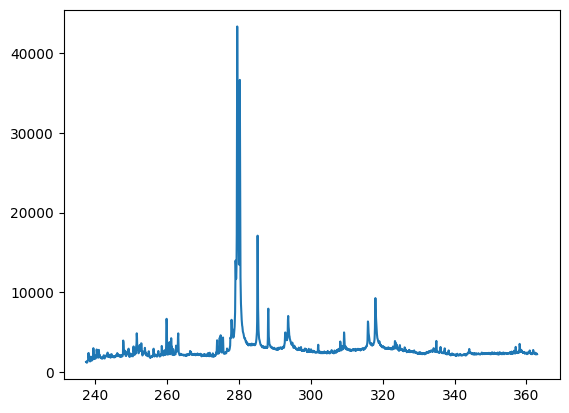

In [14]:
#Leer archivos
UV1 = "2.E2E_olivine/Olivine_LIBS_shot01_7324767SP.txt" 
UV2 = "2.E2E_olivine/Olivine_LIBS_shot01_7324768SP.txt" 
VIS = "2.E2E_olivine/Olivine_LIBS_shot01_7324769SP.txt" 
NIR = "2.E2E_olivine/Olivine_LIBS_shot01_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)

espectro_UV1 = datos_UV1['Scope Corrected for Dark'].values
wavelength = datos_UV1['Wave'].values

#Le quitamos los extremos que no aportan nada
espectro_UV1 = espectro_UV1[16:-16]
wavelength = wavelength[16:-16]
plt.plot(wavelength, espectro_UV1)


#### Quitamos el ruido de los espectros

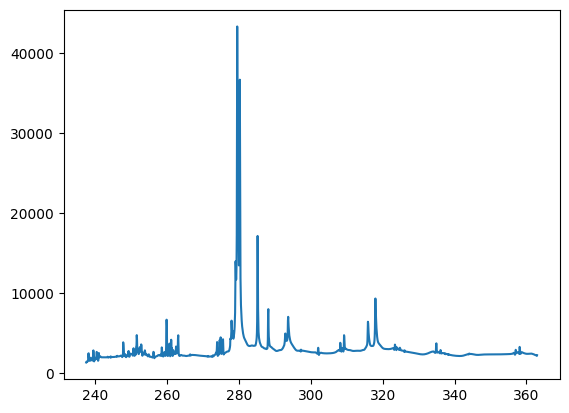

In [15]:
from denoising_fun import  denoise_spectrum_uwt
espectro_UV1 = denoise_spectrum_uwt(espectro_UV1)
plt.plot(wavelength, espectro_UV1)

## Explicación general del funcionamiento Wavelet Baseline Removal

In [16]:
#Definimos parámetros
wavelet = pywt.Wavelet('db13') #Se pueden usar las "Daubechie’s wavelets" 'db13'
L = 5
level = L  # usaremos el nivel 6 como escala de trabajo

### Aseguramos que el espectro tenga el tamaño adecuado, calculamos los coeficientes y los mínimos
1. Para poder hacer una transformación wavelet correcta nos aseguramos de que el espectro tenga un numero de puntos múltiplo de 2^L. Si no lo tiene buscamos el múltiplo más cercano y hacemos un padding.
2. Calculamos los coeficientes de la transformada no decimada wavelet (UWT), solo tomamos los de aproximación (que nos dan una idea general del espectro)
3. Buscamos los mínimos de esos coeficientes

In [17]:
# Aseguramos que el tamaño sea múltiplo de 2^level
spectrum_padded, pad_size = pad_to_multiple(espectro_UV1, 2**level)
coeffs = pywt.swt(spectrum_padded, wavelet, level=level)
cA_L = coeffs[L - 1][0]  # accedemos a la escala L con los coeficientes de aproximación

x = np.arange(len(spectrum_padded))

#Buscamos mínimos locales
minima_idxs = argrelextrema(cA_L, np.less_equal)[0]

### Refinamos los mínimos locales
A partir de los mínimos encontrados en la componente de aproximación cA de la descomposición wavelet, buscamos el mínimo real más cercano en el espectro original dentro de una ventana centrada en cada uno y de tamaño .
+ Hacemos ventanas de +-2^L alrededor de cada local minimo por que lo pone así en documento de SuperCam
+ "minima are found in the original input spectrum within windows of ±2^L around each local minimum from the decomposed signal"

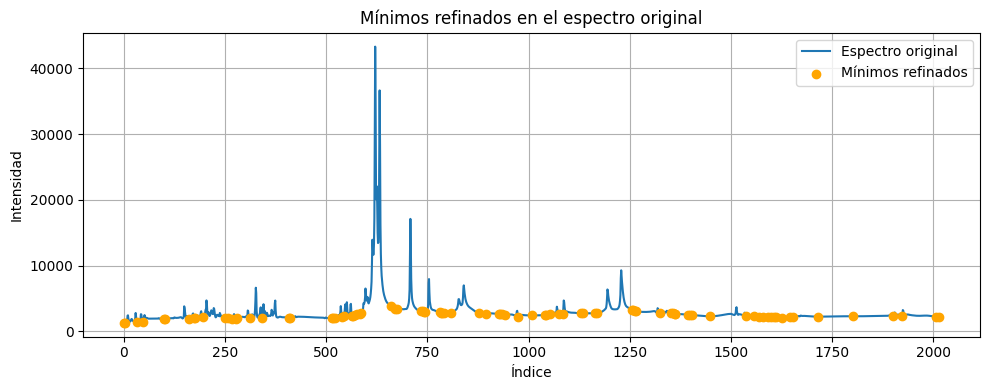

In [18]:
refined_minima_idxs = []
for idx in minima_idxs:
    start = max(0, idx - 2 ** L) #Usamos max para no salirnos del array
    end = min(len(spectrum_padded), idx + 2 ** L + 1) #Usamos min para no salirnos del array
    #Buscamos el minimo local en el rango de la ventana que damos
    local_min_idx = np.argmin(spectrum_padded[start:end]) + start #devuelve un índice relativo al start, por eso sumamos start
    refined_minima_idxs.append(local_min_idx)

refined_minima_idxs = np.unique(refined_minima_idxs)

# Visualización 2: mínimos refinados sobre el espectro original
plt.figure(figsize=(10, 4))
plt.plot(spectrum_padded, label="Espectro original")
plt.scatter(refined_minima_idxs, spectrum_padded[refined_minima_idxs],
            color='orange', label='Mínimos refinados', zorder=5)
plt.title("Mínimos refinados en el espectro original")
plt.xlabel("Índice")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Creamos un Spline y lo ajustamos al contínuo
Crea una spline cúbica interpolante que pase exactamente por todos esos puntos mínimos.

Un spline es una curva suave que pasa por un conjunto de puntos y que no tiene esquinas ni saltos bruscos. Se llama spline cúbica porque entre cada par de puntos, la forma de la cuerda se calcula usando una función polinómica de grado 3 (un polinomio cúbico).

In [19]:
# Coge los valores de los mínimos en el espectro original
x_min = np.array(refined_minima_idxs)
y_min = spectrum_padded[x_min]

spline = CubicSpline(x_min, y_min)
continuum = spline(np.arange(len(spectrum_padded)))

### Corregimos el espectro
Restamos este spline al espectro original para quitar ese "offset" vertical

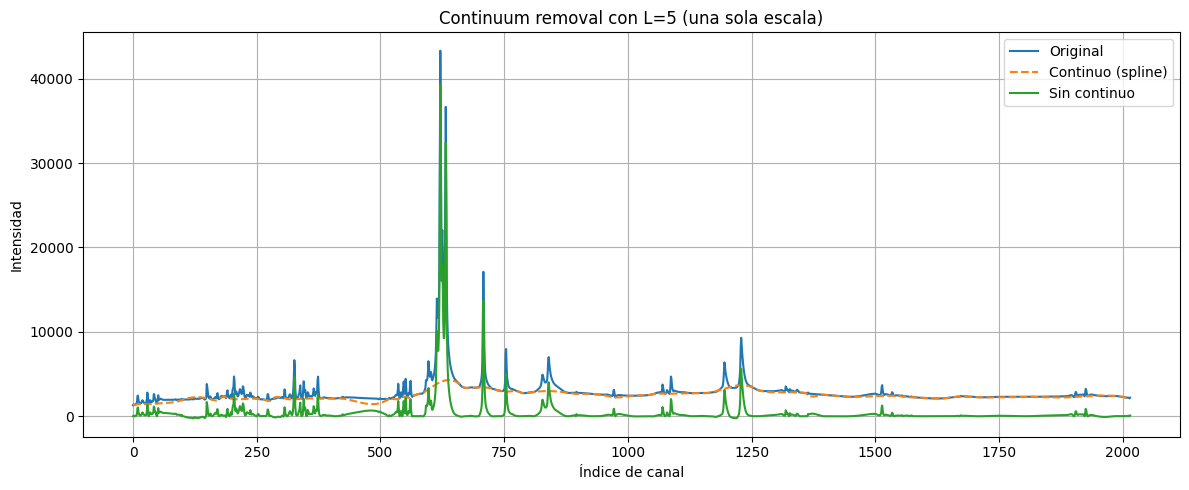

In [20]:
spectrum_corrected = spectrum_padded - continuum
spectrum_corrected = spectrum_corrected[:len(espectro_UV1)]  # quitar padding
continuum = continuum[:len(espectro_UV1)]

plt.figure(figsize=(12, 5))
plt.plot(espectro_UV1, label="Original")
plt.plot(continuum, label="Continuo (spline)", linestyle='--')
plt.plot(spectrum_corrected, label="Sin continuo")
plt.legend()
plt.title("Continuum removal con L=5 (una sola escala)")
plt.xlabel("Índice de canal")
plt.ylabel("Intensidad")
plt.grid(True)
plt.tight_layout()
plt.show()

## Código para ver distintas escalas wavelet

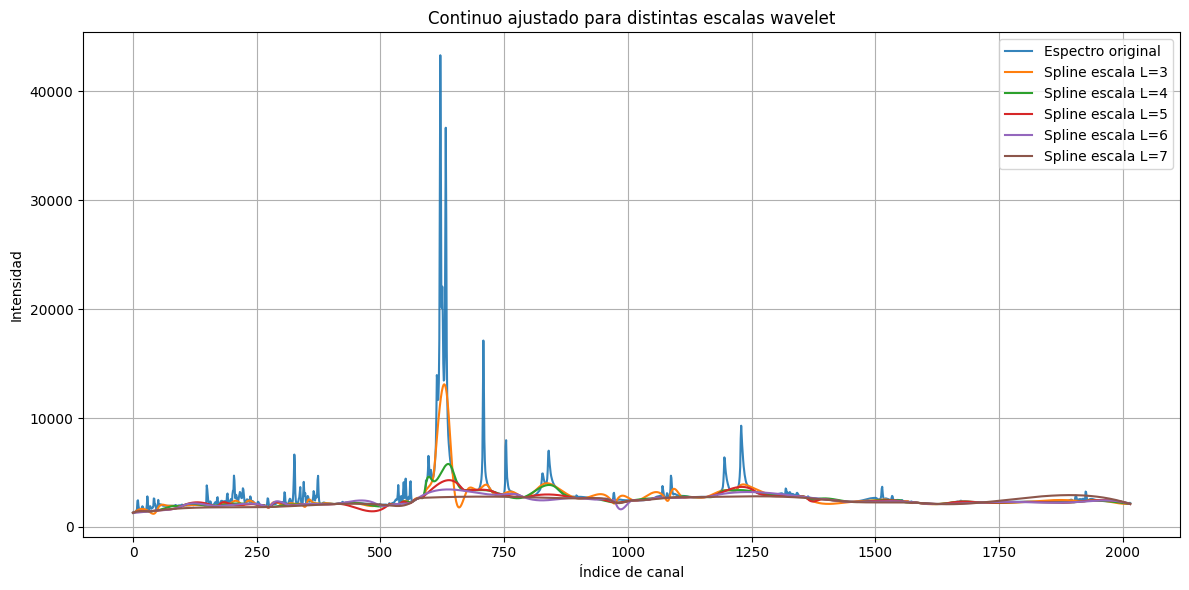

In [21]:
# Parámetros
wavelet = pywt.Wavelet("db13")
max_level = 7
spectrum = espectro_UV1

splines_per_scale = []

# Para cada nivel de escala, calcular spline del continuo
for L in range(3, max_level + 1):

    spectrum_padded, pad_size = pad_to_multiple(spectrum, 2**L)
    x_padded = np.arange(len(spectrum_padded))

    # Descomposición SWT
    coeffs = pywt.swt(spectrum_padded, wavelet, level=L)
    cA_L = coeffs[L - 1][0]
    minima_idxs = argrelextrema(cA_L, np.less)[0]

    refined_minima_idxs = []
    for idx in minima_idxs:
        start = max(0, idx - 2 ** L)
        end = min(len(spectrum_padded), idx + 2 ** L + 1)
        local_min_idx = np.argmin(spectrum_padded[start:end]) + start
        refined_minima_idxs.append(local_min_idx)
    refined_minima_idxs = np.unique(refined_minima_idxs)


    x_min = np.array(refined_minima_idxs)
    y_min = spectrum_padded[x_min]

    # Solo si hay suficientes mínimos
    if len(x_min) >= 4:
        spline = CubicSpline(x_min, y_min)
        spline_vals = spline(x_padded)
        splines_per_scale.append((L, spline_vals[:len(spectrum)]))

# Gráfica con los distintos continuos por escala
plt.figure(figsize=(12, 6))
plt.plot(spectrum, label="Espectro original",  alpha=0.9)
for L, spline_vals in splines_per_scale:
    plt.plot(spline_vals, label=f"Spline escala L={L}")
plt.title("Continuo ajustado para distintas escalas wavelet")
plt.xlabel("Índice de canal")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Probamos otros algoritmos para quitar el baseline

### Rolling Ball

Este método imagina una esfera que rueda por debajo del espectro, trazando la línea base al tocar los puntos más bajos. El proceso se divide en tres etapas:

1. Identificación de mínimos locales: Se divide el espectro en ventanas de tamaño `wm`, y se encuentra el mínimo en cada ventana.
2. Selección de máximos entre mínimos: Entre los mínimos locales identificados, se seleccionan los máximos para evitar que la línea base siga picos negativos o ruido.
3. Suavizado: Se aplica un suavizado, generalmente una media móvil con ventana `ws`, para obtener una línea base continua y suave.



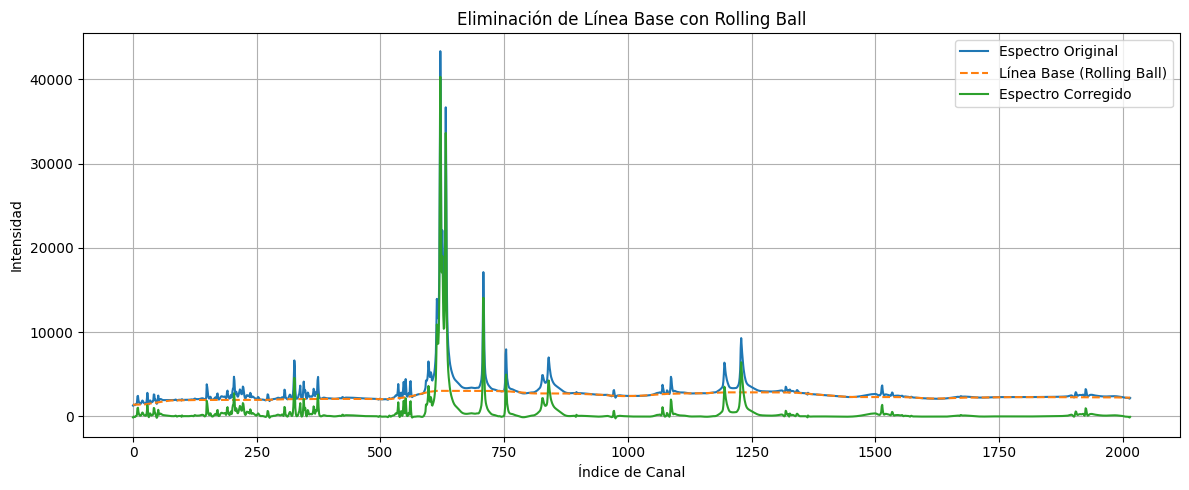

In [22]:
from scipy.ndimage import minimum_filter, maximum_filter, uniform_filter

def rolling_ball_baseline(spectrum, wm=430, ws=175):
    """
    Calcula la línea base de un espectro utilizando el algoritmo Rolling Ball.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wm : int, opcional
        Ancho de la ventana para la minimización/maximización. Por defecto 430.
    ws : int, opcional
        Ancho de la ventana para el suavizado. Por defecto 175.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    # Paso 1: Identificar mínimos locales en ventanas de tamaño wm
    minima = minimum_filter(spectrum, size=wm)

    # Paso 2: Identificar máximos entre los mínimos locales
    maxima_of_minima = maximum_filter(minima, size=wm)

    # Paso 3: Suavizar la línea base utilizando una media móvil de tamaño ws
    baseline = uniform_filter(maxima_of_minima, size=ws)

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline

    return baseline, spectrum_corrected



# Calcular la línea base y el espectro corregido
baseline, spectrum_corrected = rolling_ball_baseline(espectro_UV1, wm=150, ws=50)

# Visualizar resultados
plt.figure(figsize=(12, 5))
plt.plot(espectro_UV1, label="Espectro Original")
plt.plot(baseline, label="Línea Base (Rolling Ball)", linestyle='--')
plt.plot(spectrum_corrected, label="Espectro Corregido")
plt.legend()
plt.title("Eliminación de Línea Base con Rolling Ball")
plt.xlabel("Índice de Canal")
plt.ylabel("Intensidad")
plt.grid(True)
plt.tight_layout()
plt.show()


### Algoritmo de Medianas Locales
Estima la línea base de un espectro mediante los siguientes pasos:
1. Cálculo de medianas locales: Para cada punto del espectro, se calcula la mediana de los valores de intensidad dentro de una ventana centrada en ese punto de tamaño `wm`. La suposición es que, con una ventana adecuada, la mediana representará la línea base local, ya que los puntos de la línea base son más frecuentes que los picos.
2. Suavizado con pesos gaussianos: Las medianas locales se suavizan aplicando una convolución con una función gaussiana de ancho `ws`. Esto asegura que la línea base estimada sea continua y libre de discontinuidades abruptas.
3. Manejo de bordes: Cerca de los extremos del espectro, donde las ventanas pueden ser asimétricas, se ajusta el tamaño de las ventanas y se normalizan los pesos gaussianos para evitar artefactos en la línea base estimada.

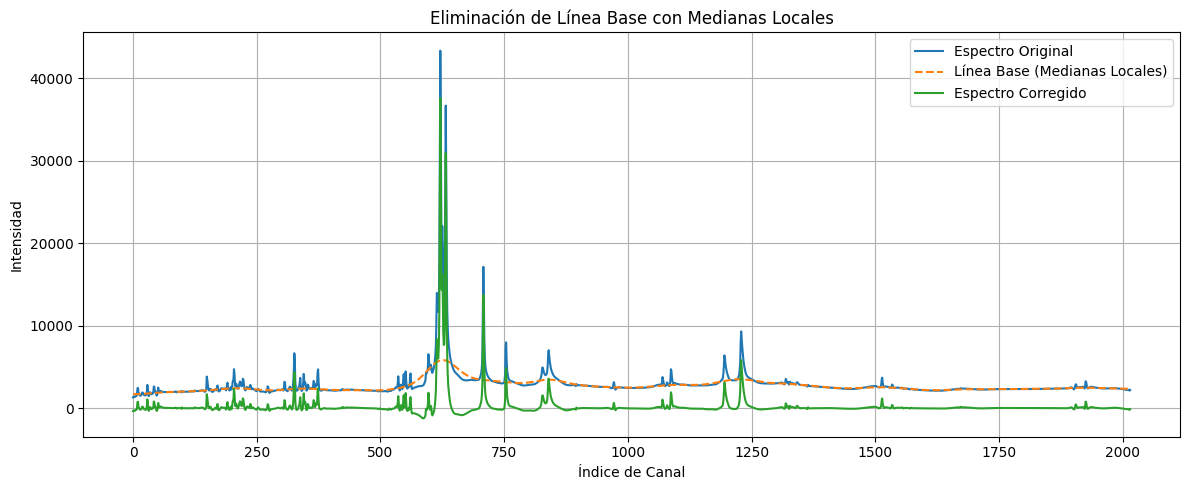

In [23]:
from scipy.ndimage import gaussian_filter1d

def local_medians_baseline(spectrum, wm=300, ws=300):
    """
    Calcula la línea base de un espectro utilizando el algoritmo de Medianas Locales.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wm : int, opcional
        Ancho de la ventana para el cálculo de medianas locales. Por defecto 300.
    ws : int, opcional
        Ancho de la ventana para el suavizado gaussiano. Por defecto 300.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    # Asegurar que el espectro es un array de NumPy
    spectrum = np.asarray(spectrum)
    n = len(spectrum)

    # Inicializar el array de medianas locales
    local_medians = np.zeros(n)

    # Calcular las medianas locales
    half_wm = wm // 2
    for i in range(n):
        start = max(0, i - half_wm)
        end = min(n, i + half_wm + 1)
        local_medians[i] = np.median(spectrum[start:end])

    # Suavizar las medianas locales con una convolución gaussiana
    baseline = gaussian_filter1d(local_medians, sigma=ws/2)

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline

    return baseline, spectrum_corrected


# Calcular la línea base y el espectro corregido
baseline, spectrum_corrected = local_medians_baseline(espectro_UV1, wm=50, ws=50)

# Visualizar resultados
plt.figure(figsize=(12, 5))
plt.plot(espectro_UV1, label="Espectro Original")
plt.plot(baseline, label="Línea Base (Medianas Locales)", linestyle='--')
plt.plot(spectrum_corrected, label="Espectro Corregido")
plt.legend()
plt.title("Eliminación de Línea Base con Medianas Locales")
plt.xlabel("Índice de Canal")
plt.ylabel("Intensidad")
plt.grid(True)
plt.tight_layout()
plt.show()


### Algoritmo RBE (Robust Baseline Estimation)
Este método se basa en una técnica llamada **Regresión Localmente Ponderada Robusta**, sirve para estimar y eliminar la línea base de un espectro sin verse afectado por los picos intensos. Es una mejora del método LOWESS, añadiendo pesos especiales que reducen la influencia de las zonas con altas intensidades (como las líneas espectrales).

El proceso funciona así:
1. Para cada punto del espectro, se considera una ventana de puntos alrededor y se ajusta una línea local (regresión lineal) que sigue la tendencia del fondo, no de los picos.
2. Los puntos más cercanos al punto central reciben más peso, usando una **función "tricúbica"** que da menos importancia a los puntos más alejados.
3. Además, se añaden **pesos robustos** usando la función bi-cuadrada de Tukey: si un punto parece ser parte de un pico (residuo grande), se le da poco peso para evitar que afecte la estimación de la línea base.
4. Este proceso se repite varias veces, refinando la línea base estimada hasta que deja de cambiar significativamente.

El resultado es una línea base suave que se ajusta al fondo del espectro, ignorando los picos. Finalmente, se resta esta línea base del espectro original para obtener un espectro corregido.

Este método es especialmente útil cuando hay muchos picos o el fondo no es plano. Los parámetros principales (`span` y `b`) controlan el tamaño de la ventana y la sensibilidad a los picos, pero los valores por defecto funcionan bien en muchos casos.

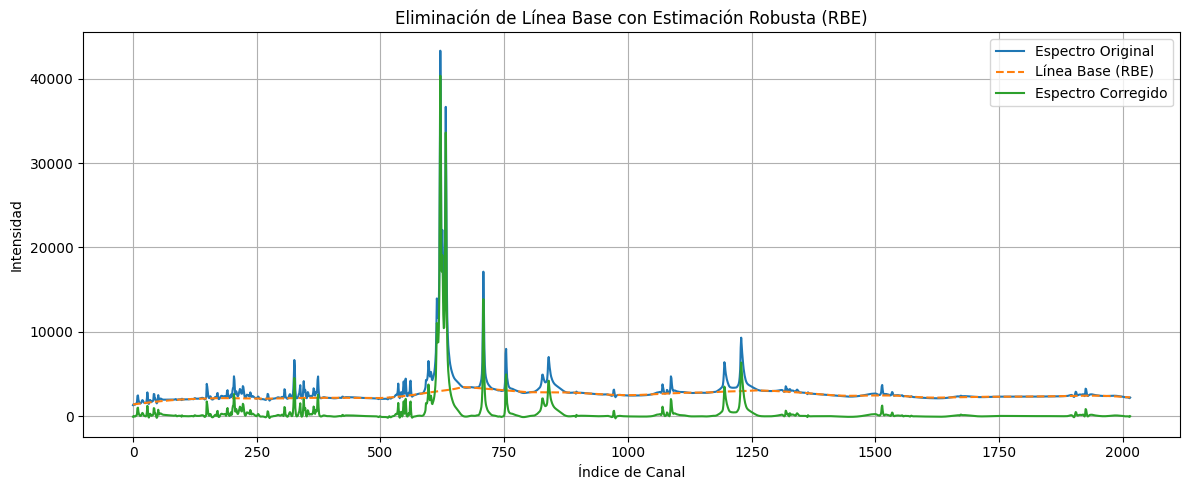

In [24]:
from scipy.stats import norm
from scipy.interpolate import interp1d

def tricube_weight(x):
    """Función de peso tricúbico."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, (1 - abs_x**3)**3, 0)

def tukey_biweight(residuals, b=3.5):
    """Pesos bi-square de Tukey asimétricos."""
    weights = np.ones_like(residuals)
    mask = residuals >= 0
    weights[mask] = (1 - (residuals[mask] / b)**2)**2
    weights[residuals >= b] = 0
    return weights

def robust_baseline_estimation(spectrum, span=0.05, max_iter=50, b=3.5, tol=1e-3):
    """
    Estima la línea base de un espectro utilizando el algoritmo RBE.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    span : float, opcional
        Proporción del total de puntos a utilizar en la regresión local. Por defecto 0.05 (5%).
    max_iter : int, opcional
        Número máximo de iteraciones para la convergencia. Por defecto 50.
    b : float, opcional
        Constante de ajuste para los pesos bi-square de Tukey. Por defecto 3.5.
    tol : float, opcional
        Tolerancia para la convergencia. Por defecto 1e-3.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    x = np.arange(len(spectrum))
    n = len(spectrum)
    half_window = int(np.ceil(span * n / 2))

    # Estimación inicial de la línea base usando LOWESS
    baseline = np.copy(spectrum)
    for i in range(n):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        x_local = x[start:end]
        y_local = spectrum[start:end]
        weights = tricube_weight((x_local - x[i]) / half_window)
        p = np.polyfit(x_local, y_local, 1, w=weights)
        baseline[i] = np.polyval(p, x[i])

    # Iteraciones para la estimación robusta
    for iteration in range(max_iter):
        residuals = spectrum - baseline
        sigma = np.median(np.abs(residuals)) / 0.6745
        residuals_standardized = residuals / sigma
        weights_robust = tukey_biweight(residuals_standardized, b)
        baseline_new = np.copy(spectrum)
        for i in range(n):
            start = max(0, i - half_window)
            end = min(n, i + half_window + 1)
            x_local = x[start:end]
            y_local = spectrum[start:end]
            weights = tricube_weight((x_local - x[i]) / half_window) * weights_robust[start:end]
            if np.sum(weights) > 0:
                p = np.polyfit(x_local, y_local, 1, w=weights)
                baseline_new[i] = np.polyval(p, x[i])
            else:
                baseline_new[i] = baseline[i]
        # Comprobar convergencia
        if np.linalg.norm(baseline_new - baseline) < tol:
            break
        baseline = baseline_new

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline

    return baseline, spectrum_corrected


# Calcular la línea base y el espectro corregido
baseline, spectrum_corrected = robust_baseline_estimation(espectro_UV1, span=0.1, max_iter=20, b=3.5)

# Visualizar resultados
plt.figure(figsize=(12, 5))
plt.plot(espectro_UV1, label="Espectro Original")
plt.plot(baseline, label="Línea Base (RBE)", linestyle='--')
plt.plot(spectrum_corrected, label="Espectro Corregido")
plt.legend()
plt.title("Eliminación de Línea Base con Estimación Robusta (RBE)")
plt.xlabel("Índice de Canal")
plt.ylabel("Intensidad")
plt.grid(True)
plt.tight_layout()
plt.show()
